## Import libraries

In [1]:
import torch
import torch.nn.functional as F
import torch.nn as nn
import torchvision.transforms.functional as TF
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import math
import numpy as np
import seaborn as sns
import torch.optim as optim
import matplotlib.pyplot as plt

# Set seed to ensure reproducibility
torch.manual_seed(0)

# Set device to GPU if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Load MNIST dataset

The MNIST database of handwritten digits has a training set of 60,000 examples, and a test set of 10,000 examples.

In [2]:
batch_size = 32
transform = transforms.ToTensor()

train_dataset = datasets.MNIST("./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST("./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

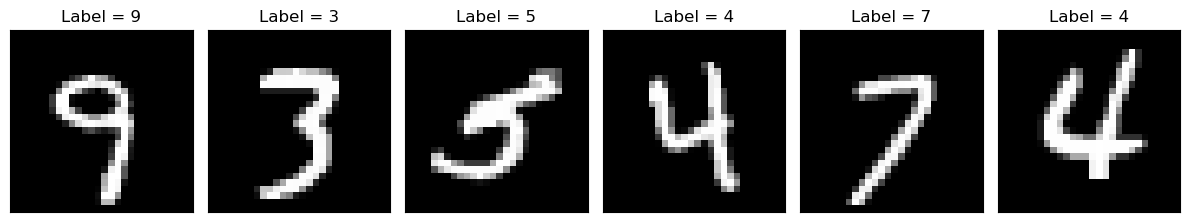

In [3]:
# Visualize some random samples from the training dataset
random_images = torch.randperm(len(train_dataset))[:6]
examples = train_dataset.data[random_images]
example_targets = train_dataset.targets[random_images]
fig = plt.figure(figsize=(12, 2.5))
for i in range(6):
    plt.subplot(1, 6, i + 1)
    plt.tight_layout()
    plt.imshow(examples[i], cmap="gray", interpolation="none")
    plt.title("Label = {}".format(example_targets[i]))
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()

## Training a NN for classification

![MNIST MLP architecture](../assets/mnist_mlp.png)

### The model: fully connected NN

In [4]:
class MLP_shallow(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MLP_shallow, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        
        self.layers = nn.Sequential(
            nn.Flatten(), # flatten the input image
            nn.Linear(self.input_size, self.hidden_size),
            nn.ReLU(),
            nn.Dropout(p=0.5), # dropout layer with 50% dropout rate
            nn.Linear(self.hidden_size, self.output_size) 
        )

    def forward(self, x):
        x = self.layers(x)
        return x

In [5]:
input_size = 28 * 28 # 784
hidden_size = 256
output_size = 10 # number of classes in MNIST
model = MLP_shallow(input_size, hidden_size, output_size).to(device)
print(model)

MLP_shallow(
  (layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [6]:
loss_fn = nn.CrossEntropyLoss()
learning_rate = 1e-4
weight_decay = 1e-5
epochs = 10
optimizer = optim.Adam(model.parameters(), lr = learning_rate, weight_decay = weight_decay)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max = epochs)

### Train the model

In [7]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)

    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary here but added for possible future use
    model.train()
    for batch, (Xbatch, Ybatch) in enumerate(dataloader):
        Xbatch, Ybatch = Xbatch.to(device), Ybatch.to(device)
        # Compute prediction and loss
        pred = model(Xbatch)
        loss = loss_fn(pred, Ybatch)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return loss.item()

def test_loop(dataloader, model, loss_fn):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    loss, correct = 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for Xbatch, Ybatch in dataloader:
            Xbatch, Ybatch = Xbatch.to(device), Ybatch.to(device)
            pred = model(Xbatch)

            correct += (pred.argmax(1) == Ybatch).type(torch.float).sum().item()

            loss += loss_fn(pred, Ybatch) * Xbatch.shape[0]
            
    correct /= size
    loss /= size

    print(f"Test metrics: Accuracy: {(100*correct):>0.1f}%, Avg loss: {loss:>8f}")

    return (100*correct), loss

In [8]:
validation_every = 5
for epoch in range(epochs):
    print(f"** Epoch {epoch+1} ", end="\r"),
    training_loss = train_loop(train_loader, model, loss_fn, optimizer)
    lr_scheduler.step()

    if ((epoch+1) % validation_every) == 0:
        print(f"\ntraining loss: {training_loss:>7f}")
        test_accuracy, test_loss = test_loop(test_loader, model, loss_fn)

** Epoch 5 
training loss: 0.280613
Test metrics: Accuracy: 94.5%, Avg loss: 0.190349
** Epoch 10 
training loss: 0.092063
Test metrics: Accuracy: 95.3%, Avg loss: 0.164900


## Monte Carlo Dropout

Training remains unchanged, while during the test loop the dropout layers (here, one layer) are kept active and predictions from multiple forward passes are collected.

In [9]:
def test_loop_mc_dropout(dataloader, model, loss_fn, T=10):
    model.train() # keep the model in training mode to enable dropout during inference
    size = len(dataloader.dataset)
    loss, correct = 0, 0

    with torch.no_grad():
        for Xbatch, Ybatch in dataloader:
            Xbatch, Ybatch = Xbatch.to(device), Ybatch.to(device)
            preds = torch.zeros((T, Xbatch.size(0), model.output_size), device=device)
            for t in range(T):
                preds[t] = model(Xbatch) 
            pred = preds.mean(dim=0)

            correct += (pred.argmax(1) == Ybatch).type(torch.float).sum().item()

            loss += loss_fn(pred, Ybatch) * Xbatch.shape[0]
            
    correct /= size
    loss /= size

    print(f"Test metrics: Accuracy: {(100*correct):>0.1f}%, Avg loss: {loss:>8f}")

    return (100*correct), loss

### Train the model with MC dropout

In [10]:
model = MLP_shallow(input_size, hidden_size, output_size).to(device)
optimizer = optim.Adam(model.parameters(), lr = learning_rate, weight_decay = weight_decay)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max = epochs)

for epoch in range(epochs):
    print(f"** Epoch {epoch+1} ", end="\r"),
    training_loss = train_loop(train_loader, model, loss_fn, optimizer)
    lr_scheduler.step()

    if ((epoch+1) % validation_every) == 0:
        print(f"\ntraining loss: {training_loss:>7f}")
        test_accuracy, test_loss = test_loop_mc_dropout(test_loader, model, loss_fn)

** Epoch 5 
training loss: 0.341964
Test metrics: Accuracy: 94.3%, Avg loss: 0.195373
** Epoch 10 
training loss: 0.052235
Test metrics: Accuracy: 95.1%, Avg loss: 0.169294


### Uncertainty Quantification

In [11]:
def tot_uncertainty(preds):
    # preds shape: (T, Batch, Classes)
    probs = F.softmax(preds, dim=-1)
    mean_probs = probs.mean(dim=0) # shape: (Batch, Classes)
    # Sum over classes (dim=-1), keep Batch dimension
    entropy = -torch.sum(mean_probs * torch.log(mean_probs + 1e-10), dim=-1)
    return entropy # shape: (Batch,)

def aleatoric_uncertainty(preds):
    # preds shape: (T, Batch, Classes)
    probs = F.softmax(preds, dim=-1)
    # Entropy per stochastic pass: (T, Batch)
    entropy_per_pass = -torch.sum(probs * torch.log(probs + 1e-10), dim=-1)
    # Average entropy over the T passes: (Batch,)
    expected_entropy = entropy_per_pass.mean(dim=0)
    return expected_entropy # shape: (Batch,)

In [12]:
# Compute predictive, aleatoric, and epistemic uncertainty on the test set
model.train()  # keep dropout active for MC sampling
T = 50

all_test_images = []
all_test_labels = []
all_test_preds = []
all_tot_u = []
all_ale_u = []
all_epi_u = []

correct, total = 0, 0
loss = 0.0

with torch.no_grad():
    for Xbatch, Ybatch in test_loader:
        Xbatch, Ybatch = Xbatch.to(device), Ybatch.to(device)
        preds = torch.zeros((T, Xbatch.size(0), model.output_size), device=device)
        for t in range(T):
            preds[t] = model(Xbatch)

        pred_mean = preds.mean(dim=0)
        tu = tot_uncertainty(preds)
        au = aleatoric_uncertainty(preds)
        eu = tu - au

        correct += (pred_mean.argmax(1) == Ybatch).type(torch.float).sum().item()
        total += Xbatch.size(0)
        loss += loss_fn(pred_mean, Ybatch).item() * Xbatch.size(0)

        all_test_images.append(Xbatch.detach().cpu())
        all_test_labels.append(Ybatch.detach().cpu())
        all_test_preds.append(pred_mean.argmax(1).detach().cpu())
        all_tot_u.append(tu.detach().cpu())
        all_ale_u.append(au.detach().cpu())
        all_epi_u.append(eu.detach().cpu())

test_accuracy = 100.0 * correct / total
test_loss = loss / total

all_test_images = torch.cat(all_test_images, dim=0)
all_test_labels = torch.cat(all_test_labels, dim=0)
all_test_preds = torch.cat(all_test_preds, dim=0)
all_tot_u = torch.cat(all_tot_u, dim=0)
all_ale_u = torch.cat(all_ale_u, dim=0)
all_epi_u = torch.cat(all_epi_u, dim=0)

print(f"MC Dropout Test metrics: Accuracy: {test_accuracy:>0.1f}%, Avg loss: {test_loss:>8f}")
print(f"Mean total uncertainty:    {all_tot_u.mean().item():.4f}")
print(f"Mean aleatoric uncertainty:{all_ale_u.mean().item():.4f}")
print(f"Mean epistemic uncertainty:{all_epi_u.mean().item():.4f}")

MC Dropout Test metrics: Accuracy: 95.2%, Avg loss: 0.168141
Mean total uncertainty:    0.3006
Mean aleatoric uncertainty:0.2662
Mean epistemic uncertainty:0.0344


**Note**: the mean uncertainties are computed over all the test samples

### Visualize the most certaion and uncertain samples

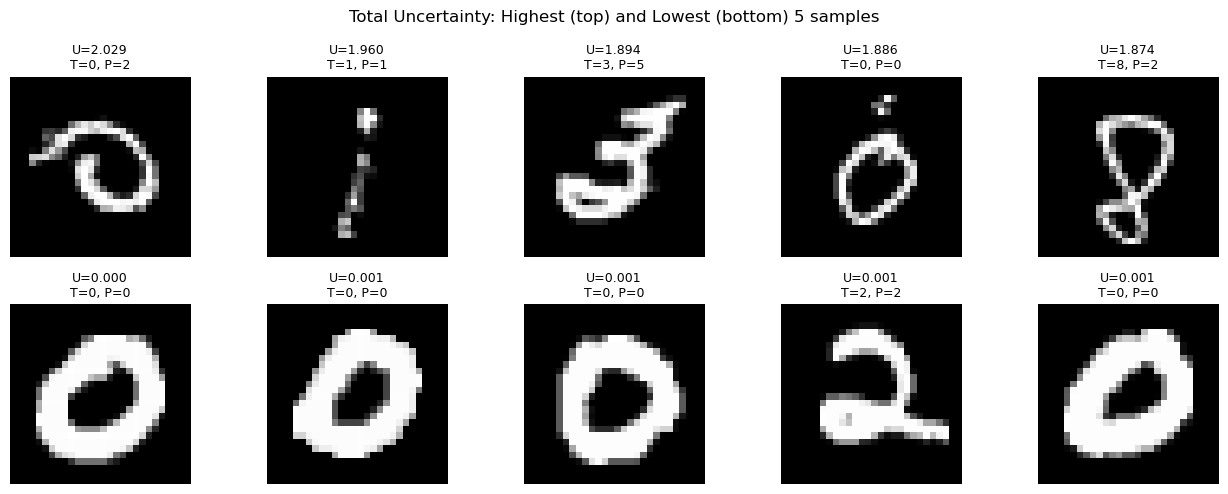

In [13]:
# Show 5 highest and 5 lowest uncertainty samples for EU and AU
k = 5
metric = all_tot_u
metric_name = "Total Uncertainty"
high_idx = torch.topk(metric, k=k, largest=True).indices
low_idx = torch.topk(metric, k=k, largest=False).indices

fig, axes = plt.subplots(2, k, figsize=(2.6 * k, 5))
fig.suptitle(f"{metric_name}: Highest (top) and Lowest (bottom) {k} samples", fontsize=12)

for i in range(k):
    h = high_idx[i].item()
    l = low_idx[i].item()

    axes[0, i].imshow(all_test_images[h][0], cmap="gray")
    axes[0, i].set_title(
        f"U={metric[h].item():.3f}\nT={all_test_labels[h].item()}, P={all_test_preds[h].item()}",
        fontsize=9
    )
    axes[0, i].axis("off")

    axes[1, i].imshow(all_test_images[l][0], cmap="gray")
    axes[1, i].set_title(
        f"U={metric[l].item():.3f}\nT={all_test_labels[l].item()}, P={all_test_preds[l].item()}",
        fontsize=9
    )
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

### First-order and second-order probabilities

Now we consider the prediction of a sequence of rotation of one image of the dataset

In [14]:
img, label = test_dataset[150]

# Create rotations from 0 to 180 degrees
angles = np.linspace(0, 180, 12)
rotated_images = []

for angle in angles:
    rotated_tensor = TF.rotate(img, -angle, interpolation=TF.InterpolationMode.BILINEAR)
    rotated_images.append(rotated_tensor)

batch_rotated = torch.stack(rotated_images).to(device)

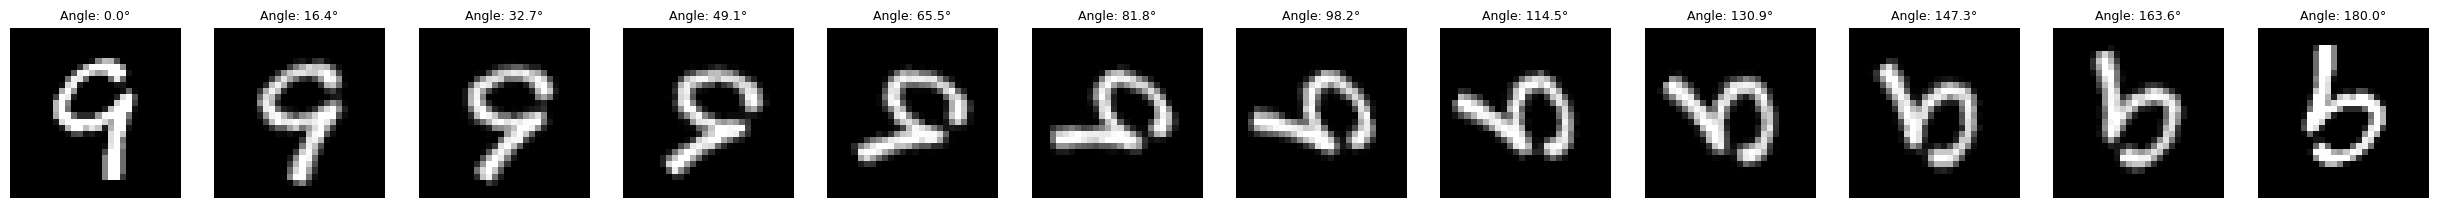

In [15]:
# Plot rotated images (12 of them)
num_images = len(angles)
fig, axes = plt.subplots(1, num_images, figsize=(2.6 * num_images, 5))
for i in range(num_images):
    axes[i].imshow(batch_rotated[i][0].cpu(), cmap="gray")
    axes[i].set_title(f"Angle: {angles[i]:.1f}°", fontsize=9)
    axes[i].axis("off")

We now compare between the predictions of a deterministic network and the MC dropout predictions

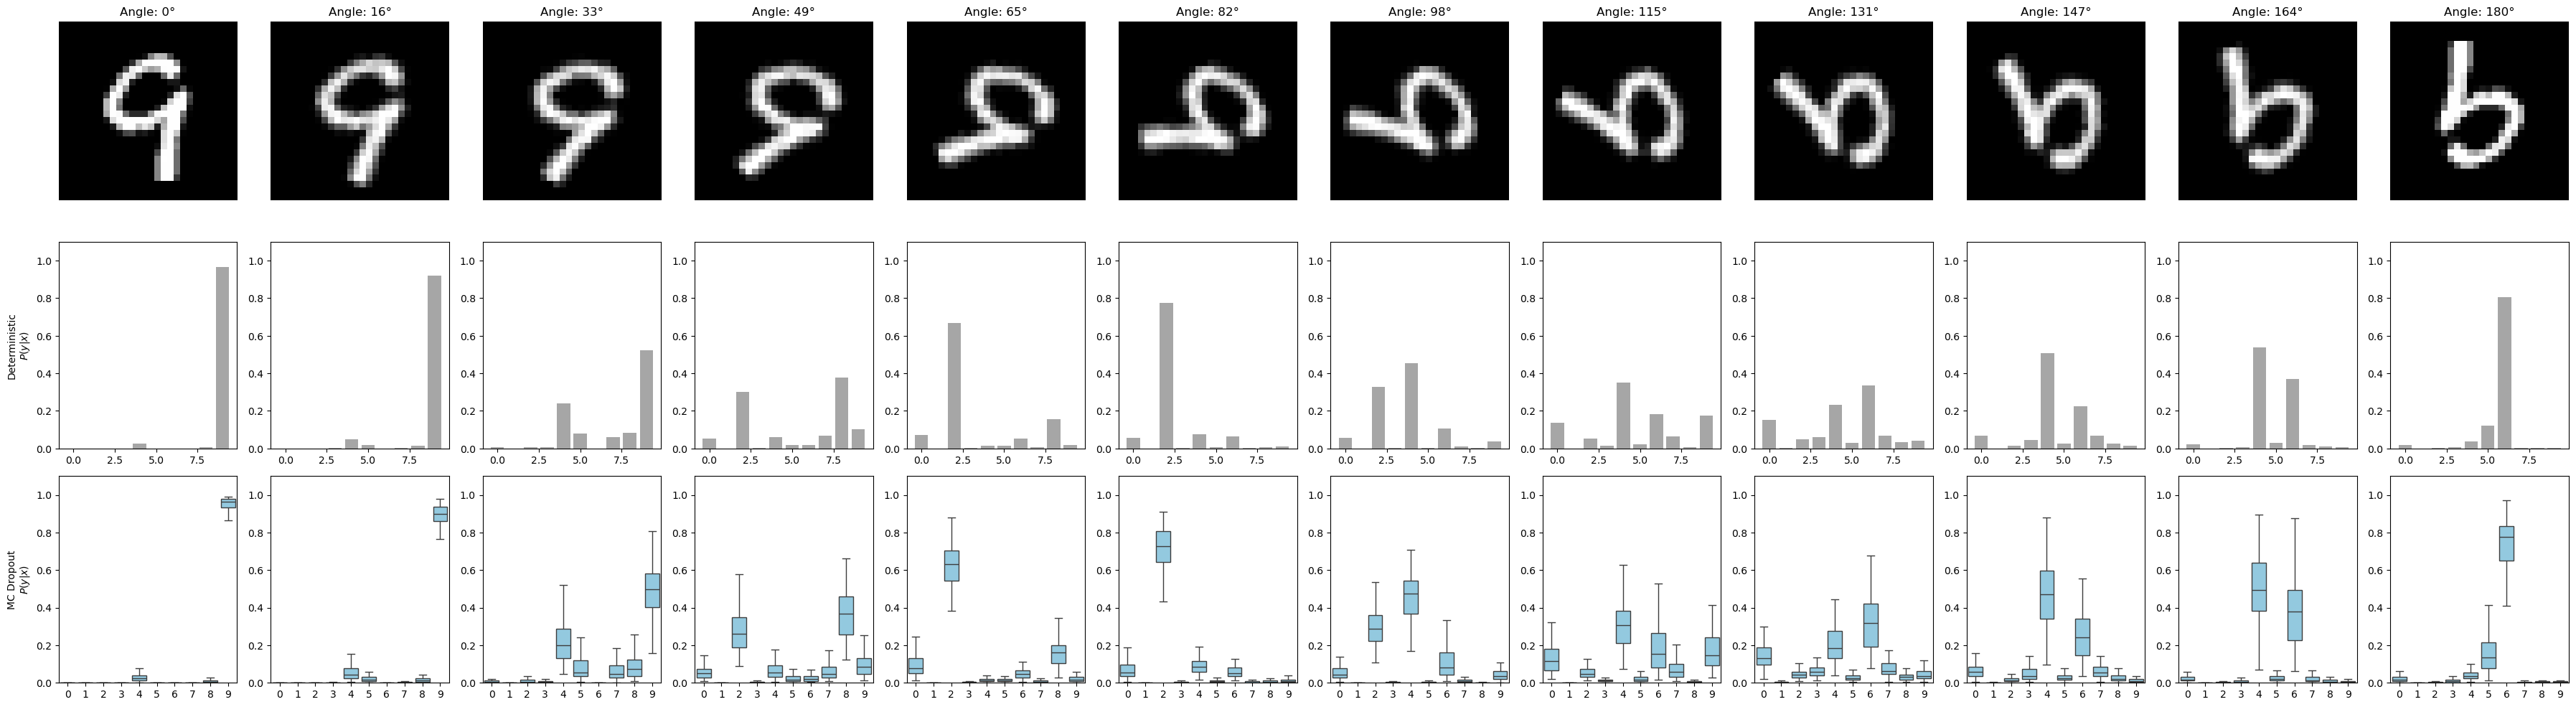

In [16]:
# 1. Get MC Dropout Predictions (Stochastic)
model.train() # Dropout ON
T = 100
all_probs_mc = []
with torch.no_grad():
    for _ in range(T):
        probs = F.softmax(model(batch_rotated), dim=-1)
        all_probs_mc.append(probs.cpu())
all_probs_mc = torch.stack(all_probs_mc).numpy() # (T, 12, 10)

# 2. Get Deterministic Predictions (Point Estimate)
model.eval() # Dropout OFF
with torch.no_grad():
    det_probs = F.softmax(model(batch_rotated), dim=-1).cpu().numpy() # (12, 10)

# 3. Plotting the Comparison
fig, axes = plt.subplots(3, num_images, figsize=(3 * num_images, 10))

for i in range(num_images):
    # Row 0: Input Image
    axes[0, i].imshow(batch_rotated[i][0].cpu(), cmap="gray")
    axes[0, i].set_title(f"Angle: {angles[i]:.0f}°")
    axes[0, i].axis("off")

    # Row 1: Deterministic (Point Estimate)
    # No Level 2 uncertainty visible here!
    axes[1, i].bar(range(10), det_probs[i], color='gray', alpha=0.7)
    axes[1, i].set_ylim(0, 1.1)
    if i == 0: axes[1, i].set_ylabel("Deterministic\n$P(y|x)$")

    # Row 2: MC Dropout (Distributional)
    # The 'Box' height is the Level 2 Epistemic Uncertainty
    sns.boxplot(data=all_probs_mc[:, i, :], ax=axes[2, i], color="skyblue", fliersize=0)
    axes[2, i].set_ylim(0, 1.1)
    if i == 0: axes[2, i].set_ylabel("MC Dropout\n$P(y|x)$")

plt.tight_layout()
plt.show()